In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
OPTIMIZER_DIRS = {
    r"uCBOpt ($\vartheta\rightarrow 0^+$)": Path("/scratch/shelvia.wongso/cbo_results/ucbopt/cifar10_resnet20/lr_0.2_wd_2e-4_h0_0.5_curv_0.0"),
    r"uCBOpt ($\vartheta=4\cdot 10^{-6}$)": Path("/scratch/shelvia.wongso/cbo_results/ucbopt/cifar10_resnet20/lr_0.2_wd_2e-4_h0_0.5_curv_5e-6"),
    "IVON ": Path("/scratch/shelvia.wongso/cbo_results/ivon_price/cifar10_resnet20/lr_0.2_wd_2e-4_h0_0.5"),
    "SGD": Path("/scratch/shelvia.wongso/cbo_results/sgd/cifar10_resnet20/lr_0.1_wd_2e-4"),
    "AdamW": Path("/scratch/shelvia.wongso/cbo_results/adamw/cifar10_resnet20/lr_2e-3_wd_2e-4"),
    "AdaHessian": Path("/scratch/shelvia.wongso/cbo_results/adahessian/cifar10_resnet20/lr_5e-2_wd_2e-4"),
}

SEEDS = range(5)

In [3]:
def find_latest_csv(seed_dir: Path, split: str) -> Path | None:
    candidates = sorted(seed_dir.glob(f"*/{split}.csv"))
    if not candidates:
        return None
    return candidates[-1]  # latest by lexicographic timestamp folder name

In [13]:
def load_split_across_seeds(root: Path, split: str, value_col: str, seeds=SEEDS):
    series_list = []

    for seed in seeds:
        seed_dir = root / f"seed={seed}"
        csv_path = find_latest_csv(seed_dir, split)

        if csv_path is None:
            print(f"[WARN] Missing {split}.csv for {root.name}, seed={seed}")
            continue

        df = pd.read_csv(csv_path)

        if "epoch" not in df.columns or value_col not in df.columns:
            print(f"[WARN] Missing required columns in {csv_path}")
            continue

        s = df[["epoch", value_col]].copy()
        s = s.rename(columns={value_col: f"seed={seed}"})
        series_list.append(s)

    if not series_list:
        return None

    # Merge on epoch so all seeds are aligned
    merged = series_list[0]
    for s in series_list[1:]:
        merged = pd.merge(merged, s, on="epoch", how="inner")

    value_cols = [c for c in merged.columns if c != "epoch"]
    merged["mean"] = merged[value_cols].mean(axis=1)
    merged["std"] = merged[value_cols].std(axis=1, ddof=1)

    return merged[["epoch", "mean", "std"]]

In [14]:
def collect_all_results(optimizer_dirs, seeds=SEEDS):
    results = {}

    metrics = {
        "train_loss": ("train", "loss"),
        "test_loss": ("test", "loss"),
        "train_acc": ("train", "acc"),
        "test_acc": ("test", "acc"),
    }

    for opt_name, root in optimizer_dirs.items():
        results[opt_name] = {}
        for metric_name, (split, col) in metrics.items():
            out = load_split_across_seeds(root, split, col, seeds=seeds)
            results[opt_name][metric_name] = out

    return results

In [21]:
def plot_metric(results, metric_name, ylabel, savepath=None):
    plt.figure(figsize=(8, 5))

    styles = {
        r"uCBOpt ($\vartheta\rightarrow 0^+$)": {
            "linewidth": 2.5,
            "zorder": 3,
        },
        r"uCBOpt ($\vartheta=4\cdot 10^{-6}$)": {
            "linestyle": ":",
            "linewidth": 2.5,
            "zorder": 4,
        },
        "IVON ": {
            "linewidth": 1.8,
        },
        "SGD": {
            "linewidth": 1.8,
        },
        "AdamW": {
            "linewidth": 1.8,
        },
        "AdaHessian": {
            "linewidth": 1.8,
        },
    }

    for opt_name, opt_results in results.items():
        df = opt_results.get(metric_name)
        if df is None:
            print(f"[WARN] No data for {opt_name} - {metric_name}")
            continue

        x = df["epoch"].to_numpy()
        y = df["mean"].to_numpy()
        std = df["std"].to_numpy()

        style = styles.get(opt_name, {})

        line, = plt.plot(x, y, label=opt_name, **style)
        line_color = line.get_color()

        plt.fill_between(
            x,
            y - std,
            y + std,
            color=line_color,
            alpha=0.15,
            zorder=style.get("zorder", 1) - 0.1,
        )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(metric_name.replace("_", " ").title())
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()

In [22]:
results = collect_all_results(OPTIMIZER_DIRS, seeds=SEEDS)

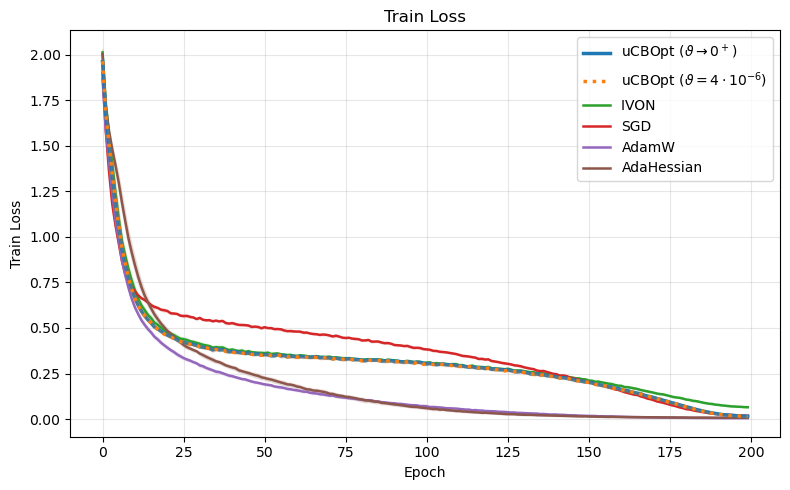

In [23]:
plot_metric(results, "train_loss", "Train Loss")

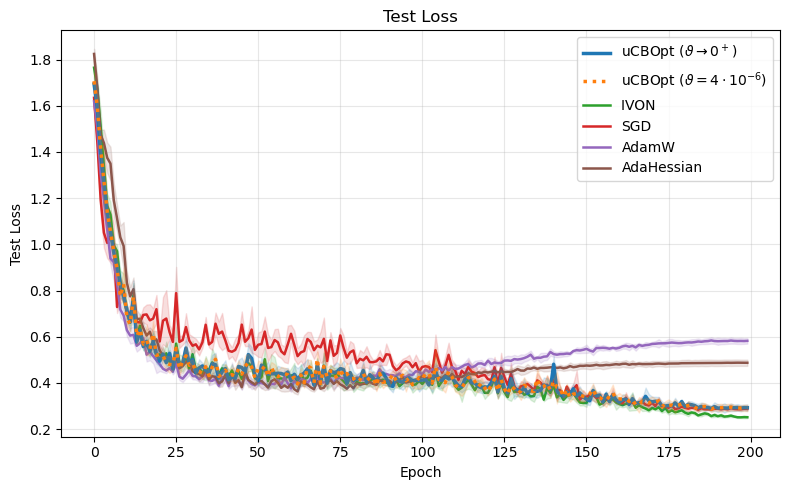

In [24]:
plot_metric(results, "test_loss", "Test Loss")

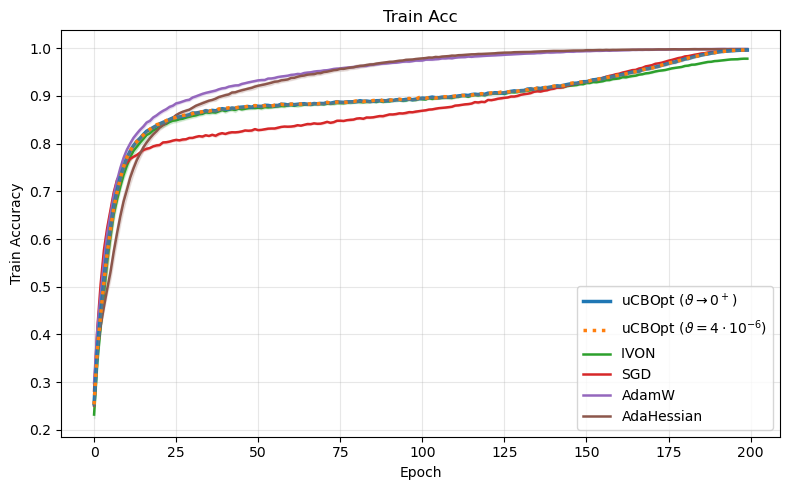

In [25]:
plot_metric(results, "train_acc", "Train Accuracy")

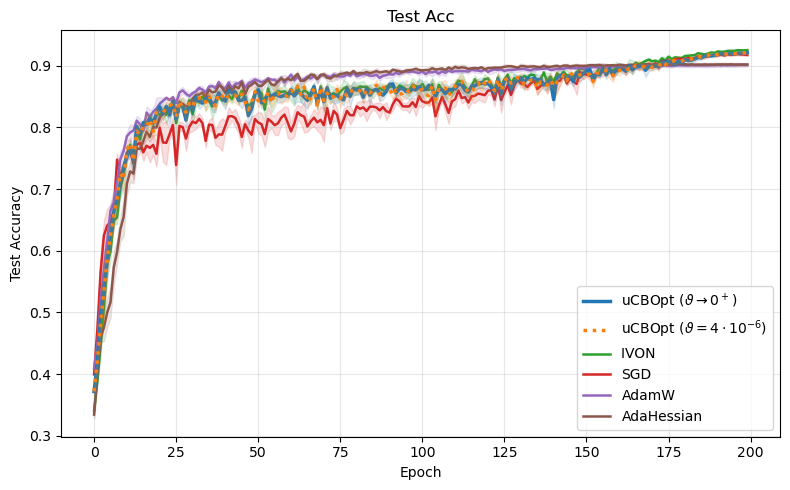

In [26]:
plot_metric(results, "test_acc", "Test Accuracy")